In [7]:
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
from scipy.sparse import csc_matrix

raw_dir = Path("../data/raw")

In [8]:
2+2

4

In [9]:
spike_path = raw_dir / "YFF" / "arithmetic" / "spikes.mat"

with h5py.File(spike_path, "r") as f:
    spikes = f["spikes"]

    data = spikes["data"][:]
    indices = spikes["ir"][:]
    indptr = spikes["jc"][:]

    n_neurons = int(spikes.attrs["MATLAB_sparse"])
    n_timepoints = len(indptr) - 1

    spike_matrix = csc_matrix(
        (data, indices, indptr),
        shape=(n_neurons, n_timepoints)
    )

print("Spike matrix shape:", spike_matrix.shape)
print("Number of spikes:", spike_matrix.nnz)

Spike matrix shape: (54, 708276)
Number of spikes: 501537


In [10]:
spike_matrix

<Compressed Sparse Column sparse matrix of dtype 'uint8'
	with 501537 stored elements and shape (54, 708276)>

In [11]:
behav_path = raw_dir / "YFF" / "arithmetic" / "photoBehavEvents.csv"

yff = pd.read_csv(behav_path)

print("Behavior shape:", yff.shape)

yff.head()

Behavior shape: (100, 22)


,trial,tCue1,tCue2,tCue3,presentationEnd,tPress1,tPress2,tPress3,keyPress1,keyPress2,...,timeFeedback,cue1,cue2,operation,operationFirst,correctAnsw,givenAnsw,correct,correctFb,toExclude
0,1,5338.733333,6089.466667,6840.200000,7607.600000,13830.233333,14030.500000,NaN,1,1.0,...,15398.433333,5,16,-,1,-11,11,0,1,0
1,2,15882.233333,16632.933333,17383.666667,18167.733333,20453.266667,NaN,NaN,3,NaN,...,21938.033333,2,1,+,0,3,3,1,1,0
2,3,22438.533333,23189.233333,23939.966667,24690.666667,26192.133333,NaN,NaN,7,NaN,...,27576.766667,6,1,+,1,7,7,1,1,0
3,4,28077.300000,28828.000000,29578.700000,30329.433333,34967.200000,35250.833333,NaN,2,1.0,...,36635.466667,0,16,+,0,16,21,0,1,0
4,5,37136.000000,37886.700000,38637.400000,39388.133333,40872.900000,41256.600000,NaN,1,6.0,...,42607.900000,10,6,+,0,16,16,1,1,0


In [12]:
def align_arithmetic_events(df, subject):
    df = df.copy()

    df["operand1_time"] = np.nan
    df["operation_time"] = np.nan
    df["operand2_time"] = np.nan

    # Special protocol
    if subject in ["YFR", "YFS"]:
        df["operand1_time"] = df["tCue1"]
        df["operation_time"] = df["tCue2"]
        df["operand2_time"] = df["tCue3"]

    else:
        # Operand1 -> Operand2 -> Operation
        mask0 = df["operationFirst"] == 0

        df.loc[mask0, "operand1_time"] = df.loc[mask0, "tCue1"]
        df.loc[mask0, "operand2_time"] = df.loc[mask0, "tCue2"]
        df.loc[mask0, "operation_time"] = df.loc[mask0, "tCue3"]

        # Operation -> Operand1 -> Operand2
        mask1 = df["operationFirst"] == 1

        df.loc[mask1, "operation_time"] = df.loc[mask1, "tCue1"]
        df.loc[mask1, "operand1_time"] = df.loc[mask1, "tCue2"]
        df.loc[mask1, "operand2_time"] = df.loc[mask1, "tCue3"]

    return df

In [13]:
yff_aligned = align_arithmetic_events(yff, "YFF")

yff_aligned[
    [
        "trial",
        "cue1",
        "operation",
        "cue2",
        "operand1_time",
        "operation_time",
        "operand2_time"
    ]
].head()

,trial,cue1,operation,cue2,operand1_time,operation_time,operand2_time
0,1,5,-,16,6089.466667,5338.733333,6840.200000
1,2,2,+,1,15882.233333,17383.666667,16632.933333
2,3,6,+,1,23189.233333,22438.533333,23939.966667
3,4,0,+,16,28077.300000,29578.700000,28828.000000
4,5,10,+,6,37136.000000,38637.400000,37886.700000


In [14]:
def decode_matlab_string(f, ref):
    obj = f[ref]
    values = obj[()].flatten()
    return "".join(chr(int(x)) for x in values)


with h5py.File(spike_path, "r") as f:
    regions = f["regionsVect"]
    refs = regions[0]

    region_labels = [
        decode_matlab_string(f, ref)
        for ref in refs
    ]

print("Number of region labels:", len(region_labels))

for i, region in enumerate(region_labels):
    print(f"Neuron {i}: {region}")
hpc_neurons = [
    i for i, region in enumerate(region_labels)
    if region == "hpc"
]

print("HPC neuron IDs:")
print(hpc_neurons)

print("Number of HPC neurons:", len(hpc_neurons))

Number of region labels: 54
Neuron 0: acc
Neuron 1: acc
Neuron 2: acc
Neuron 3: acc
Neuron 4: acc
Neuron 5: acc
Neuron 6: acc
Neuron 7: acc
Neuron 8: ent
Neuron 9: hpc
Neuron 10: hpc
Neuron 11: hpc
Neuron 12: hpc
Neuron 13: hpc
Neuron 14: hpc
Neuron 15: hpc
Neuron 16: hpc
Neuron 17: acc
Neuron 18: acc
Neuron 19: acc
Neuron 20: acc
Neuron 21: acc
Neuron 22: acc
Neuron 23: acc
Neuron 24: acc
Neuron 25: acc
Neuron 26: hpc
Neuron 27: hpc
Neuron 28: hpc
Neuron 29: hpc
Neuron 30: hpc
Neuron 31: hpc
Neuron 32: hpc
Neuron 33: hpc
Neuron 34: hpc
Neuron 35: hpc
Neuron 36: hpc
Neuron 37: hpc
Neuron 38: hpc
Neuron 39: hpc
Neuron 40: hpc
Neuron 41: hpc
Neuron 42: hpc
Neuron 43: hpc
Neuron 44: hpc
Neuron 45: hpc
Neuron 46: hpc
Neuron 47: hpc
Neuron 48: hpc
Neuron 49: hpc
Neuron 50: hpc
Neuron 51: hpc
Neuron 52: hpc
Neuron 53: hpc
HPC neuron IDs:
[9, 10, 11, 12, 13, 14, 15, 16, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53]
Number of HP

In [15]:
neuron_id = hpc_neurons[0]

In [16]:
# Select Trial 1
trial = yff_aligned.iloc[0]

# Operand 1 onset
operand1_time = trial["operand1_time"]

# Paper's arithmetic analysis window:
# 50 ms to 950 ms after operand onset
start_ms = int(round(operand1_time + 50))
end_ms   = int(round(operand1_time + 950))

# Start with neuron 0
neuron_id = hpc_neurons[0]

# Extract this neuron's spike train during the window
spikes_window = spike_matrix[
    neuron_id,
    start_ms:end_ms
]

print("Trial:", int(trial["trial"]))
print("Operand 1:", trial["cue1"])
print("Operand 1 onset:", operand1_time, "ms")

print("\nWindow start:", start_ms, "ms")
print("Window end:", end_ms, "ms")
print("Window length:", spikes_window.shape[1], "ms")

print("\nNeuron:", neuron_id)
print("Number of spikes:", spikes_window.sum())

Trial: 1
Operand 1: 5
Operand 1 onset: 6089.46666666667 ms

Window start: 6139 ms
Window end: 7039 ms
Window length: 900 ms

Neuron: 9
Number of spikes: 16


In [17]:
spike_positions = spikes_window.nonzero()[1]

# Because our window begins 50 ms after operand onset
relative_spike_times = spike_positions + 50

print("Number of spikes:", len(relative_spike_times))
print("Spike times relative to Operand 1 onset (ms):")
print(relative_spike_times)

Number of spikes: 16
Spike times relative to Operand 1 onset (ms):
[154 311 347 374 401 433 534 548 564 586 662 800 826 828 845 912]


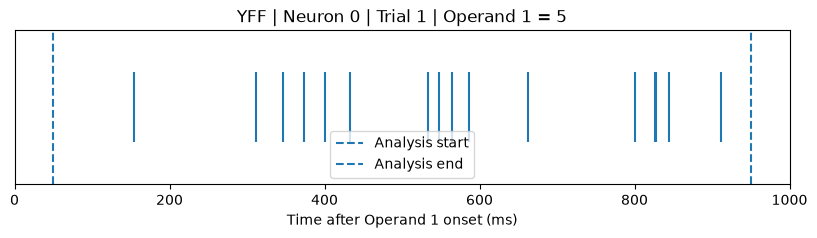

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 2))

plt.eventplot(
    relative_spike_times,
    lineoffsets=1,
    linelengths=0.7
)

plt.axvline(50, linestyle="--", label="Analysis start")
plt.axvline(950, linestyle="--", label="Analysis end")

plt.xlim(0, 1000)
plt.yticks([])

plt.xlabel("Time after Operand 1 onset (ms)")
plt.title("YFF | Neuron 0 | Trial 1 | Operand 1 = 5")

plt.legend()
plt.show()

In [19]:
neuron_id

trial_responses = []

for _, trial in yff_aligned.iterrows():

    operand1 = trial["cue1"]
    onset = trial["operand1_time"]

    start_ms = int(round(onset + 50))
    end_ms   = int(round(onset + 950))

    # Extract this neuron's 900-ms response
    window = spike_matrix[
        neuron_id,
        start_ms:end_ms
    ]

    spike_count = window.sum()

    # 900 ms = 0.9 seconds
    firing_rate = spike_count / 0.9

    trial_responses.append({
        "trial": int(trial["trial"]),
        "operand1": operand1,
        "spike_count": int(spike_count),
        "firing_rate_hz": float(firing_rate),
        "correct": trial["correct"],
        "toExclude": trial["toExclude"]
    })

neuron0_responses = pd.DataFrame(trial_responses)

neuron0_responses.head(10)

,trial,operand1,spike_count,firing_rate_hz,correct,toExclude
0,1,5,16,17.777778,0,0
1,2,2,19,21.111111,1,0
2,3,6,15,16.666667,1,0
3,4,0,11,12.222222,0,0
4,5,10,20,22.222222,1,0
5,6,9,11,12.222222,1,0
6,7,5,17,18.888889,0,0
7,8,8,11,12.222222,1,0
8,9,9,12,13.333333,1,0
9,10,0,8,8.888889,0,0


In [20]:
neuron0_responses

,trial,operand1,spike_count,firing_rate_hz,correct,toExclude
0,1,5,16,17.777778,0,0
1,2,2,19,21.111111,1,0
2,3,6,15,16.666667,1,0
3,4,0,11,12.222222,0,0
4,5,10,20,22.222222,1,0
...,...,...,...,...,...,...
95,96,2,22,24.444444,1,0
96,97,12,13,14.444444,0,0
97,98,7,12,13.333333,1,0
98,99,13,23,25.555556,1,0


In [21]:
print("Last spike-matrix column:", spike_matrix.shape[1] - 1)

print("Last behavioral trial:")
print(yff_aligned.iloc[-1][
    ["trial", "tCue1", "tCue2", "tCue3",
     "presentationEnd", "choiceEnd", "timeFeedback"]
])

last_feedback = yff_aligned["timeFeedback"].max()

print("\nRecording length:", spike_matrix.shape[1], "ms")
print("Last feedback:", last_feedback, "ms")
print("Remaining neural recording:",
      spike_matrix.shape[1] - last_feedback, "ms")

Last spike-matrix column: 708275
Last behavioral trial:
trial                        100
tCue1              701090.433333
tCue2              701824.433333
tCue3              702575.166667
presentationEnd    703325.866667
choiceEnd          707129.533333
timeFeedback            707646.7
Name: 99, dtype: object

Recording length: 708276 ms
Last feedback: 707646.7 ms
Remaining neural recording: 629.3000000000466 ms


In [22]:
def decode_matlab_string(f, ref):
    obj = f[ref]
    values = obj[()].flatten()
    return "".join(chr(int(x)) for x in values)


with h5py.File(spike_path, "r") as f:
    regions = f["regionsVect"]
    refs = regions[0]

    region_labels = [
        decode_matlab_string(f, ref)
        for ref in refs
    ]

print("Number of region labels:", len(region_labels))

for i, region in enumerate(region_labels):
    print(f"Neuron {i}: {region}")
hpc_neurons = [
    i for i, region in enumerate(region_labels)
    if region == "hpc"
]

print("HPC neuron IDs:")
print(hpc_neurons)

print("Number of HPC neurons:", len(hpc_neurons))

Number of region labels: 54
Neuron 0: acc
Neuron 1: acc
Neuron 2: acc
Neuron 3: acc
Neuron 4: acc
Neuron 5: acc
Neuron 6: acc
Neuron 7: acc
Neuron 8: ent
Neuron 9: hpc
Neuron 10: hpc
Neuron 11: hpc
Neuron 12: hpc
Neuron 13: hpc
Neuron 14: hpc
Neuron 15: hpc
Neuron 16: hpc
Neuron 17: acc
Neuron 18: acc
Neuron 19: acc
Neuron 20: acc
Neuron 21: acc
Neuron 22: acc
Neuron 23: acc
Neuron 24: acc
Neuron 25: acc
Neuron 26: hpc
Neuron 27: hpc
Neuron 28: hpc
Neuron 29: hpc
Neuron 30: hpc
Neuron 31: hpc
Neuron 32: hpc
Neuron 33: hpc
Neuron 34: hpc
Neuron 35: hpc
Neuron 36: hpc
Neuron 37: hpc
Neuron 38: hpc
Neuron 39: hpc
Neuron 40: hpc
Neuron 41: hpc
Neuron 42: hpc
Neuron 43: hpc
Neuron 44: hpc
Neuron 45: hpc
Neuron 46: hpc
Neuron 47: hpc
Neuron 48: hpc
Neuron 49: hpc
Neuron 50: hpc
Neuron 51: hpc
Neuron 52: hpc
Neuron 53: hpc
HPC neuron IDs:
[9, 10, 11, 12, 13, 14, 15, 16, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53]
Number of HP

In [23]:
neuron_id = hpc_neurons[0]

In [24]:
neuron_id

9

In [25]:
neuron_responses = pd.DataFrame(trial_responses)

In [26]:
operand1_tuning = (
    neuron_responses
    .groupby("operand1")
    .agg(
        n_trials=("trial", "count"),
        mean_firing_rate=("firing_rate_hz", "mean"),
        std_firing_rate=("firing_rate_hz", "std")
    )
    .reset_index()
)

operand1_tuning

,operand1,n_trials,mean_firing_rate,std_firing_rate
0,0,10,13.333333,3.008903
1,1,4,17.222222,1.924501
2,2,4,15.277778,9.179284
3,3,5,16.222222,3.975232
4,4,2,13.888889,2.357023
5,5,6,17.592593,1.635511
6,6,10,16.888889,3.696289
7,7,9,16.419753,4.836135
8,8,5,17.555556,5.055250
9,9,10,15.333333,6.170864


In [27]:
operand1_tuning["n_trials"].sum()

np.int64(100)

In [28]:
neuron_responses = pd.DataFrame(trial_responses)

In [29]:
neuron_responses

,trial,operand1,spike_count,firing_rate_hz,correct,toExclude
0,1,5,16,17.777778,0,0
1,2,2,19,21.111111,1,0
2,3,6,15,16.666667,1,0
3,4,0,11,12.222222,0,0
4,5,10,20,22.222222,1,0
...,...,...,...,...,...,...
95,96,2,22,24.444444,1,0
96,97,12,13,14.444444,0,0
97,98,7,12,13.333333,1,0
98,99,13,23,25.555556,1,0


In [30]:
1+1

2

In [31]:
valid_operand1 = neuron_responses[
    (neuron_responses["toExclude"] == 0) &
    (neuron_responses["operand1"].between(1, 9))
].copy()

valid_operand1

,trial,operand1,spike_count,firing_rate_hz,correct,toExclude
0,1,5,16,17.777778,0,0
1,2,2,19,21.111111,1,0
2,3,6,15,16.666667,1,0
5,6,9,11,12.222222,1,0
6,7,5,17,18.888889,0,0
7,8,8,11,12.222222,1,0
8,9,9,12,13.333333,1,0
10,11,6,10,11.111111,0,0
11,12,1,15,16.666667,1,0
12,13,2,4,4.444444,1,0


In [32]:
valid_operand1["operand1"].value_counts().sort_index()

operand1
1     4
2     4
3     5
4     2
5     6
6    10
7     9
8     5
9    10
Name: count, dtype: int64

In [33]:
print("Original rows:", len(neuron_responses))
print("Valid rows:", len(valid_operand1))
print("Shape:", valid_operand1.shape)

Original rows: 100
Valid rows: 55
Shape: (55, 6)


In [34]:
tuning_1to9 = (
    valid_operand1
    .groupby("operand1")
    .agg(
        n_trials=("trial", "count"),
        mean_firing_rate=("firing_rate_hz", "mean"),
        sem_firing_rate=("firing_rate_hz", "sem")
    )
    .reset_index()
)

tuning_1to9

,operand1,n_trials,mean_firing_rate,sem_firing_rate
0,1,4,17.222222,0.962250
1,2,4,15.277778,4.589642
2,3,5,16.222222,1.777778
3,4,2,13.888889,1.666667
4,5,6,17.592593,0.667695
5,6,10,16.888889,1.168869
6,7,9,16.419753,1.612045
7,8,5,17.555556,2.260777
8,9,10,15.333333,1.951398


In [35]:
tuning_1to9["n_trials"].sum()

np.int64(55)

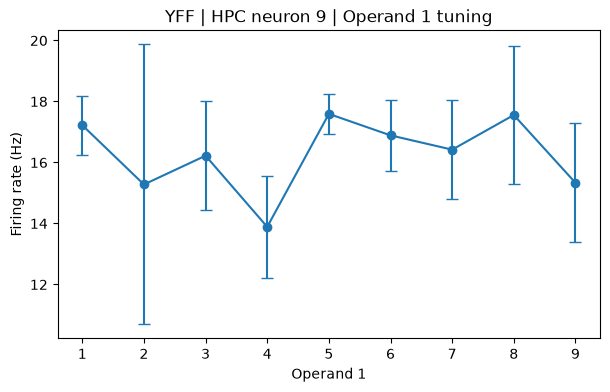

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

plt.errorbar(
    tuning_1to9["operand1"],
    tuning_1to9["mean_firing_rate"],
    yerr=tuning_1to9["sem_firing_rate"],
    marker="o",
    capsize=4
)

plt.xticks(range(1, 10))
plt.xlabel("Operand 1")
plt.ylabel("Firing rate (Hz)")
plt.title(f"YFF | HPC neuron {neuron_id} | Operand 1 tuning")

plt.show()

For YFF, hippocampal neuron 9, the plot shows the mean firing rate during the 50–950 ms Operand-1 window, separately for numbers 1–9. The vertical error bars are the SEM. Standard Error of the Mean.across repeated trials for each number.

A few observations: the response varies roughly from 14 to 18 Hz. Numbers 5 and 8 have relatively higher means, while 4 is lower. Number 2 has a particularly large error bar because we only had 4 presentations and the trial-to-trial responses were highly variable.

---


extract the same 50–950 ms window relative to operand2_time, restrict to values 1–9, and then compare Operand-1 and Operand-2 responses.

# Extract Operand-2 responses for all 100 trials

In [37]:
neuron_id = hpc_neurons[0]   # YFF HPC neuron 9

operand2_responses = []

for _, trial in yff_aligned.iterrows():

    operand2 = trial["cue2"]
    onset = trial["operand2_time"]

    # 50–950 ms after Operand 2 onset
    start_ms = int(round(onset + 50))
    end_ms   = int(round(onset + 950))

    window = spike_matrix[
        neuron_id,
        start_ms:end_ms
    ]

    spike_count = window.sum()

    # 900 ms = 0.9 seconds
    firing_rate = spike_count / 0.9

    operand2_responses.append({
        "trial": int(trial["trial"]),
        "operand2": operand2,
        "spike_count": int(spike_count),
        "firing_rate_hz": float(firing_rate),
        "correct": trial["correct"],
        "toExclude": trial["toExclude"]
    })

operand2_responses = pd.DataFrame(operand2_responses)

operand2_responses

,trial,operand2,spike_count,firing_rate_hz,correct,toExclude
0,1,16,20,22.222222,0,0
1,2,1,10,11.111111,1,0
2,3,1,8,8.888889,1,0
3,4,16,12,13.333333,0,0
4,5,6,13,14.444444,1,0
...,...,...,...,...,...,...
95,96,10,14,15.555556,1,0
96,97,2,19,21.111111,0,0
97,98,3,15,16.666667,1,0
98,99,11,22,24.444444,1,0


# Filter to numbers 1–9

In [38]:
valid_operand2 = operand2_responses[
    (operand2_responses["toExclude"] == 0) &
    (operand2_responses["operand2"].between(1, 9))
].copy()

print("Original rows:", len(operand2_responses))
print("Valid rows:", len(valid_operand2))

valid_operand2["operand2"].value_counts().sort_index()

Original rows: 100
Valid rows: 54


operand2
1     6
2    11
3     6
4     5
5     1
6     6
7     8
8     7
9     4
Name: count, dtype: int64

# Calculate mean and SEM

In [39]:
tuning_operand2 = (
    valid_operand2
    .groupby("operand2")
    .agg(
        n_trials=("trial", "count"),
        mean_firing_rate=("firing_rate_hz", "mean"),
        sem_firing_rate=("firing_rate_hz", "sem")
    )
    .reset_index()
)

tuning_operand2

,operand2,n_trials,mean_firing_rate,sem_firing_rate
0,1,6,14.259259,1.911987
1,2,11,19.696970,1.315460
2,3,6,15.925926,1.453438
3,4,5,14.666667,2.615245
4,5,1,16.666667,NaN
5,6,6,15.925926,1.873942
6,7,8,18.888889,2.241976
7,8,7,15.873016,1.904762
8,9,4,16.944444,1.835577


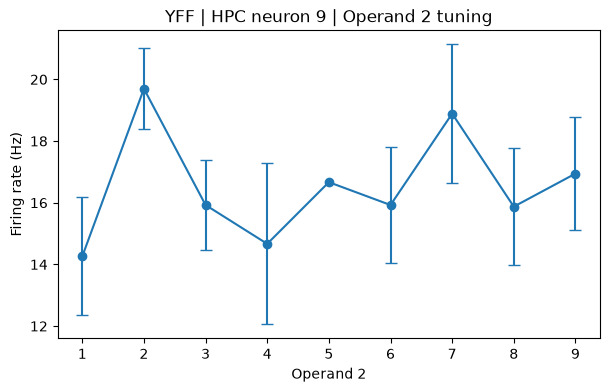

In [40]:
plt.figure(figsize=(7, 4))

plt.errorbar(
    tuning_operand2["operand2"],
    tuning_operand2["mean_firing_rate"],
    yerr=tuning_operand2["sem_firing_rate"],
    marker="o",
    capsize=4
)

plt.xticks(range(1, 10))
plt.xlabel("Operand 2")
plt.ylabel("Firing rate (Hz)")
plt.title(f"YFF | HPC neuron {neuron_id} | Operand 2 tuning")

plt.show()

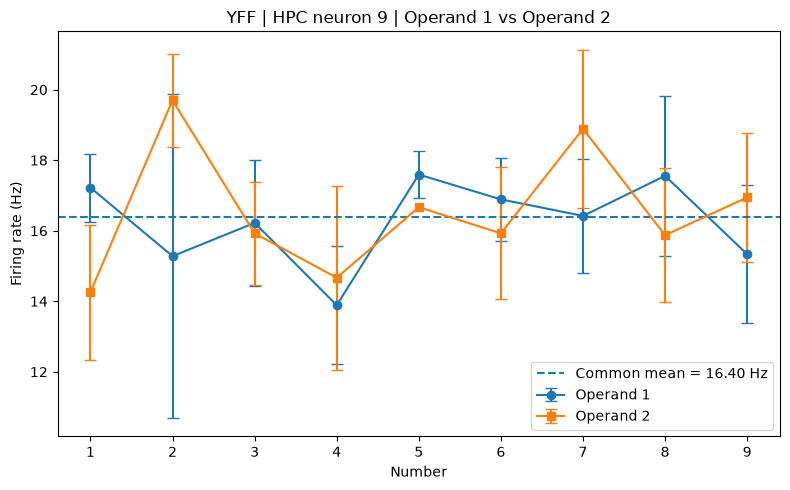

Common mean firing rate: 16.40 Hz


In [41]:
import matplotlib.pyplot as plt
import pandas as pd

# Merge the two tuning tables by numerical value
comparison = pd.merge(
    tuning_1to9,
    tuning_operand2,
    left_on="operand1",
    right_on="operand2",
    suffixes=("_op1", "_op2")
)

# Common reference = mean firing rate across the two curves
common_mean = (
    comparison["mean_firing_rate_op1"].mean()
    + comparison["mean_firing_rate_op2"].mean()
) / 2

plt.figure(figsize=(8, 5))

# Operand 1
plt.errorbar(
    comparison["operand1"],
    comparison["mean_firing_rate_op1"],
    yerr=comparison["sem_firing_rate_op1"],
    marker="o",
    capsize=4,
    label="Operand 1"
)

# Operand 2
plt.errorbar(
    comparison["operand2"],
    comparison["mean_firing_rate_op2"],
    yerr=comparison["sem_firing_rate_op2"],
    marker="s",
    capsize=4,
    label="Operand 2"
)

# Horizontal reference line
plt.axhline(
    common_mean,
    linestyle="--",
    label=f"Common mean = {common_mean:.2f} Hz"
)

plt.xticks(range(1, 10))
plt.xlabel("Number")
plt.ylabel("Firing rate (Hz)")
plt.title(f"YFF | HPC neuron {neuron_id} | Operand 1 vs Operand 2")

plt.legend()
plt.tight_layout()
plt.show()

print(f"Common mean firing rate: {common_mean:.2f} Hz")

---

Figure 1D reproduce on YFU hpc 43

Ques : what do index 43 mean here ? hpc 43 , matlab index or python index ??

actual YFU data tell us:

YFU has 78 total units
39 of those rows are labeled / hpc
raw row 43 is amy

So YFU.hpc.43 cannot mean “43rd HPC row in this processed regionsVect”, because there are only 39 HPC rows.

YFU spike matrix

In [42]:
yfu_spike_path = raw_dir / "YFU" / "arithmetic" / "spikes.mat"
yfu_behav_path = raw_dir / "YFU" / "arithmetic" / "photoBehavEvents.csv"

with h5py.File(yfu_spike_path, "r") as f:
    spikes = f["spikes"]

    yfu_spike_matrix = csc_matrix(
        (
            spikes["data"][:],
            spikes["ir"][:],
            spikes["jc"][:]
        ),
        shape=(
            int(spikes.attrs["MATLAB_sparse"]),
            len(spikes["jc"]) - 1
        )
    )

print("YFU spike matrix:", yfu_spike_matrix.shape)

yfu = pd.read_csv(yfu_behav_path)

print("YFU behavioral table:", yfu.shape)

YFU spike matrix: (78, 2273935)
YFU behavioral table: (300, 22)


In [43]:
with h5py.File(yfu_spike_path, "r") as f:
    regions = f["regionsVect"]

    yfu_region_labels = [
        decode_matlab_string(f, ref)
        for ref in regions[0]
    ]

print("Total units:", len(yfu_region_labels))

Total units: 78


In [44]:
yfu_hpc_neurons = [
    i for i, region in enumerate(yfu_region_labels)
    if region == "hpc"
]

print("YFU HPC row indices:")
print(yfu_hpc_neurons)

print("Number of YFU HPC units:", len(yfu_hpc_neurons))

YFU HPC row indices:
[20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69]
Number of YFU HPC units: 39


In [45]:
print("Python row 43 region:", yfu_region_labels[43])

if len(yfu_hpc_neurons) >= 43:
    print("43rd HPC unit, MATLAB-style counting:", yfu_hpc_neurons[42])

if len(yfu_hpc_neurons) >= 44:
    print("HPC unit at Python position 43:", yfu_hpc_neurons[43])

Python row 43 region: amy


In [46]:
from pathlib import Path

yfu_dir = raw_dir / "YFU"

for path in sorted(yfu_dir.rglob("*")):
    if path.is_file():
        print(path.relative_to(yfu_dir))

.DS_Store
arithmetic\photoBehavEvents.csv
arithmetic\photoBehavEvents.mat
arithmetic\spikes.mat
dot\photoBehavEvents.mat
dot\spikes.mat


In [47]:
with h5py.File(yfu_spike_path, "r") as f:

    print("TOP-LEVEL OBJECTS")
    print(list(f.keys()))

    print("\nFILE ATTRIBUTES")
    for key, value in f.attrs.items():
        print(key, ":", value)

    print("\nALL HDF5 OBJECTS")

    def show_object(name, obj):
        print(
            name,
            "| type:", type(obj).__name__,
            "| shape:", getattr(obj, "shape", None),
            "| attrs:", dict(obj.attrs)
        )

    f.visititems(show_object)

TOP-LEVEL OBJECTS
['#refs#', 'regionsVect', 'spikes']

FILE ATTRIBUTES

ALL HDF5 OBJECTS
#refs# | type: Group | shape: None | attrs: {}
#refs#/0 | type: Dataset | shape: (3, 1) | attrs: {'H5PATH': np.bytes_(b'/#refs#/0'), 'MATLAB_class': np.bytes_(b'char'), 'MATLAB_int_decode': np.int32(2)}
#refs#/1 | type: Dataset | shape: (3, 1) | attrs: {'H5PATH': np.bytes_(b'/#refs#/1'), 'MATLAB_class': np.bytes_(b'char'), 'MATLAB_int_decode': np.int32(2)}
#refs#/2 | type: Dataset | shape: (3, 1) | attrs: {'H5PATH': np.bytes_(b'/#refs#/2'), 'MATLAB_class': np.bytes_(b'char'), 'MATLAB_int_decode': np.int32(2)}
#refs#/3 | type: Dataset | shape: (3, 1) | attrs: {'H5PATH': np.bytes_(b'/#refs#/3'), 'MATLAB_class': np.bytes_(b'char'), 'MATLAB_int_decode': np.int32(2)}
#refs#/4 | type: Dataset | shape: (3, 1) | attrs: {'H5PATH': np.bytes_(b'/#refs#/4'), 'MATLAB_class': np.bytes_(b'char'), 'MATLAB_int_decode': np.int32(2)}
#refs#/5 | type: Dataset | shape: (3, 1) | attrs: {'H5PATH': np.bytes_(b'/#refs#/5')

lets backtrack to find the number id , using the plot 

In [48]:
# First align YFU behavioral events
yfu_aligned = align_arithmetic_events(yfu, "YFU")

# Figure 1D reference profile, approximated from the published panel
reference_numbers = np.arange(1, 10)

reference_fr = np.array([
    6.5,   # 1
    6.75,  # 2
    7.3,   # 3
    6.3,   # 4
    7.2,   # 5
    7.1,   # 6
    6.0,   # 7
    6.2,   # 8
    7.1    # 9
])

In [49]:
def compute_operand_tuning_for_neuron(spike_matrix, behav_aligned, neuron_id):
    rows = []

    for _, trial in behav_aligned.iterrows():

        if trial["toExclude"] != 0:
            continue

        for operand_col, time_col, position in [
            ("cue1", "operand1_time", 1),
            ("cue2", "operand2_time", 2)
        ]:
            number = trial[operand_col]

            if not (1 <= number <= 9):
                continue

            onset = trial[time_col]

            start_ms = int(round(onset + 50))
            end_ms   = int(round(onset + 950))

            window = spike_matrix[
                neuron_id,
                start_ms:end_ms
            ]

            spike_count = window.sum()
            firing_rate = spike_count / 0.9

            rows.append({
                "number": int(number),
                "firing_rate_hz": float(firing_rate),
                "operand_position": position
            })

    df = pd.DataFrame(rows)

    tuning = (
        df.groupby("number")
        .agg(
            n_trials=("firing_rate_hz", "count"),
            mean_firing_rate=("firing_rate_hz", "mean"),
            sem_firing_rate=("firing_rate_hz", "sem")
        )
        .reindex(range(1, 10))
        .reset_index()
    )

    return tuning

In [50]:
candidate_rows = []
candidate_tunings = {}

for neuron_id in yfu_hpc_neurons:

    tuning = compute_operand_tuning_for_neuron(
        yfu_spike_matrix,
        yfu_aligned,
        neuron_id
    )

    candidate_tunings[neuron_id] = tuning

    curve = tuning["mean_firing_rate"].to_numpy()

    if np.any(np.isnan(curve)):
        continue

    # Absolute mismatch with published Figure 1D profile
    rmse = np.sqrt(np.mean((curve - reference_fr) ** 2))

    # Shape correlation
    corr = np.corrcoef(curve, reference_fr)[0, 1]

    candidate_rows.append({
        "neuron_id": neuron_id,
        "region": yfu_region_labels[neuron_id],
        "mean_rate": curve.mean(),
        "rmse_vs_fig1d": rmse,
        "corr_vs_fig1d": corr
    })

candidate_summary = pd.DataFrame(candidate_rows)

In [51]:
candidate_summary.sort_values(
    ["rmse_vs_fig1d", "corr_vs_fig1d"],
    ascending=[True, False]
).head(10)

,neuron_id,region,mean_rate,rmse_vs_fig1d,corr_vs_fig1d
22,42,hpc,6.725591,0.027259,0.998522
20,40,hpc,7.480033,0.897329,0.485609
31,62,hpc,5.652446,1.185682,0.023852
17,37,hpc,7.732679,1.188165,-0.117096
25,56,hpc,7.871648,1.388754,-0.378001
13,33,hpc,8.219126,1.548439,0.720682
26,57,hpc,4.969220,1.813169,0.243557
29,60,hpc,4.583661,2.222932,-0.591674
1,21,hpc,4.513659,2.276845,-0.246050
23,54,hpc,4.313247,2.468135,-0.124581


YFU.hpc.43 in Figure 1D⟷Python spike-matrix row 42 ,, in Matlab its 43 , in python its 42

In [52]:
fig1d_tuning = candidate_tunings[42]

fig1d_tuning

,number,n_trials,mean_firing_rate,sem_firing_rate
0,1,53,6.477987,0.379480
1,2,67,6.766169,0.330593
2,3,52,7.307692,0.416530
3,4,62,6.308244,0.360240
4,5,51,7.189542,0.400137
5,6,48,7.129630,0.392605
6,7,65,6.068376,0.309202
7,8,49,6.190476,0.369424
8,9,47,7.092199,0.356932


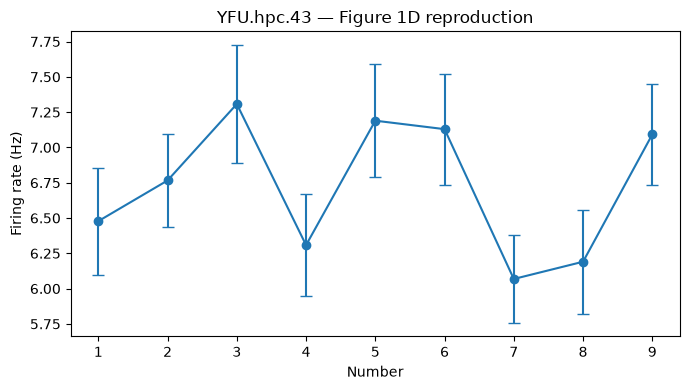

In [53]:
plt.figure(figsize=(7, 4))

plt.errorbar(
    fig1d_tuning["number"],
    fig1d_tuning["mean_firing_rate"],
    yerr=fig1d_tuning["sem_firing_rate"],
    marker="o",
    capsize=4
)

plt.xticks(range(1, 10))
plt.xlabel("Number")
plt.ylabel("Firing rate (Hz)")
plt.title("YFU.hpc.43 — Figure 1D reproduction")

plt.tight_layout()
plt.show()

In [54]:
fig1d_tuning[
    ["number", "n_trials", "mean_firing_rate", "sem_firing_rate"]
]

,number,n_trials,mean_firing_rate,sem_firing_rate
0,1,53,6.477987,0.379480
1,2,67,6.766169,0.330593
2,3,52,7.307692,0.416530
3,4,62,6.308244,0.360240
4,5,51,7.189542,0.400137
5,6,48,7.129630,0.392605
6,7,65,6.068376,0.309202
7,8,49,6.190476,0.369424
8,9,47,7.092199,0.356932


do again on neuron_id = 42


In [55]:
neuron_id = 42

print("Neuron row:", neuron_id)
print("Region:", yfu_region_labels[neuron_id])


Neuron row: 42
Region: hpc


algo :

determine Operand 1 and its actual onset;
take 50–950 ms after onset;
count spikes from row 42;
calculate FR=N/0.9;
do the same independently for Operand 2;
keep numbers 1–9 and non-excluded trials;
pool the operand presentations;
group by number;
calculate mean FR and SEM;
plot.

## Figure 1D — YFU.hpc.43 independent reconstruction

In [56]:
responses = []

for _, trial in yfu_aligned.iterrows():

    # Skip trials marked for exclusion
    if trial["toExclude"] != 0:
        continue

    # -------------------------
    # Operand 1
    # -------------------------
    number = int(trial["cue1"])
    onset = trial["operand1_time"]

    if 1 <= number <= 9:

        start_ms = int(round(onset + 50))
        end_ms   = int(round(onset + 950))

        spike_count = yfu_spike_matrix[
            neuron_id,
            start_ms:end_ms
        ].sum()

        responses.append({
            "trial": int(trial["trial"]),
            "operand_position": 1,
            "number": number,
            "spike_count": int(spike_count),
            "firing_rate_hz": float(spike_count / 0.9)
        })

    # -------------------------
    # Operand 2
    # -------------------------
    number = int(trial["cue2"])
    onset = trial["operand2_time"]

    if 1 <= number <= 9:

        start_ms = int(round(onset + 50))
        end_ms   = int(round(onset + 950))

        spike_count = yfu_spike_matrix[
            neuron_id,
            start_ms:end_ms
        ].sum()

        responses.append({
            "trial": int(trial["trial"]),
            "operand_position": 2,
            "number": number,
            "spike_count": int(spike_count),
            "firing_rate_hz": float(spike_count / 0.9)
        })


yfu43_responses = pd.DataFrame(responses)

yfu43_responses

,trial,operand_position,number,spike_count,firing_rate_hz
0,1,1,7,6,6.666667
1,1,2,8,7,7.777778
2,2,1,7,6,6.666667
3,2,2,4,7,7.777778
4,3,1,7,7,7.777778
...,...,...,...,...,...
489,297,1,6,6,6.666667
490,298,1,4,8,8.888889
491,298,2,5,5,5.555556
492,299,1,4,8,8.888889


In [57]:
print("Total number presentations:", len(yfu43_responses))

print("\nPresentations by operand position:")
print(
    yfu43_responses["operand_position"]
    .value_counts()
    .sort_index()
)

print("\nPresentations of each number:")
print(
    yfu43_responses["number"]
    .value_counts()
    .sort_index()
)

Total number presentations: 494

Presentations by operand position:
operand_position
1    244
2    250
Name: count, dtype: int64

Presentations of each number:
number
1    53
2    67
3    52
4    62
5    51
6    48
7    65
8    49
9    47
Name: count, dtype: int64


In [58]:
yfu43_tuning = (
    yfu43_responses
    .groupby("number")
    .agg(
        n_presentations=("firing_rate_hz", "count"),
        mean_firing_rate=("firing_rate_hz", "mean"),
        sem_firing_rate=("firing_rate_hz", "sem")
    )
    .reindex(range(1, 10))
    .reset_index()
)

yfu43_tuning

,number,n_presentations,mean_firing_rate,sem_firing_rate
0,1,53,6.477987,0.379480
1,2,67,6.766169,0.330593
2,3,52,7.307692,0.416530
3,4,62,6.308244,0.360240
4,5,51,7.189542,0.400137
5,6,48,7.129630,0.392605
6,7,65,6.068376,0.309202
7,8,49,6.190476,0.369424
8,9,47,7.092199,0.356932


mean fr = sum of fr in oper1 +op2 / number of presentations

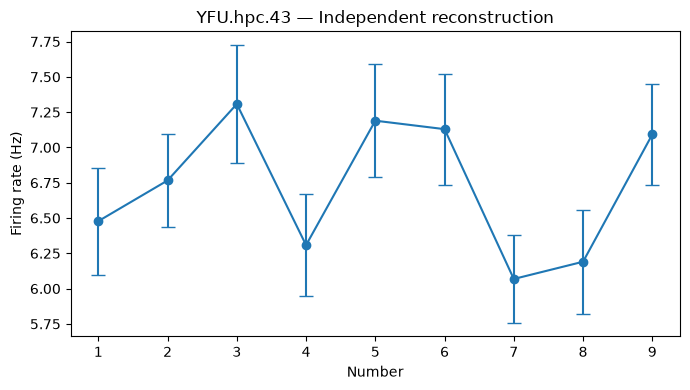

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

plt.errorbar(
    yfu43_tuning["number"],
    yfu43_tuning["mean_firing_rate"],
    yerr=yfu43_tuning["sem_firing_rate"],
    marker="o",
    capsize=5
)

plt.xticks(range(1, 10))

plt.xlabel("Number")
plt.ylabel("Firing rate (Hz)")
plt.title("YFU.hpc.43 — Independent reconstruction")

plt.tight_layout()
plt.show()

notes :
Operand displayed for 750 ms, but analyze the neuron's response over a 900-ms window from 50–950 ms relative to its onset.


raw spike matrix, behavioral timestamps, event alignment, spike counting, firing rates, trial repetitions, mean/SEM, operand-specific tuning

---

In [61]:
neuron_id = 42

responses = []

for _, trial in yfu_aligned.iterrows():

    if trial["toExclude"] != 0:
        continue

    for number_col, time_col, position in [
        ("cue1", "operand1_time", 1),
        ("cue2", "operand2_time", 2),
    ]:

        number = int(trial[number_col])

        if not (1 <= number <= 9):
            continue

        onset = trial[time_col]

        start_ms = int(round(onset + 50))
        end_ms   = int(round(onset + 950))

        spike_count = yfu_spike_matrix[
            neuron_id,
            start_ms:end_ms
        ].sum()

        responses.append({
            "trial": int(trial["trial"]),
            "operand_position": position,
            "number": number,
            "spike_count": int(spike_count),
            "firing_rate_hz": float(spike_count / 0.9)
        })

yfu43_responses = pd.DataFrame(responses)

In [62]:
yfu43_tuning = (
    yfu43_responses
    .groupby("number")
    .agg(
        n_presentations=("firing_rate_hz", "count"),
        mean_firing_rate=("firing_rate_hz", "mean"),
        sem_firing_rate=("firing_rate_hz", "sem")
    )
    .reindex(range(1, 10))
    .reset_index()
)

yfu43_tuning

,number,n_presentations,mean_firing_rate,sem_firing_rate
0,1,53,6.477987,0.379480
1,2,67,6.766169,0.330593
2,3,52,7.307692,0.416530
3,4,62,6.308244,0.360240
4,5,51,7.189542,0.400137
5,6,48,7.129630,0.392605
6,7,65,6.068376,0.309202
7,8,49,6.190476,0.369424
8,9,47,7.092199,0.356932


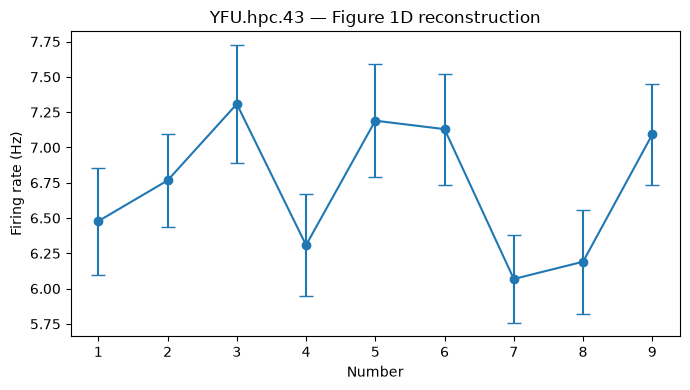

In [63]:
plt.figure(figsize=(7, 4))

plt.errorbar(
    yfu43_tuning["number"],
    yfu43_tuning["mean_firing_rate"],
    yerr=yfu43_tuning["sem_firing_rate"],
    marker="o",
    capsize=5
)

plt.xticks(range(1, 10))
plt.xlabel("Number")
plt.ylabel("Firing rate (Hz)")
plt.title("YFU.hpc.43 — Figure 1D reconstruction")

plt.tight_layout()
plt.show()

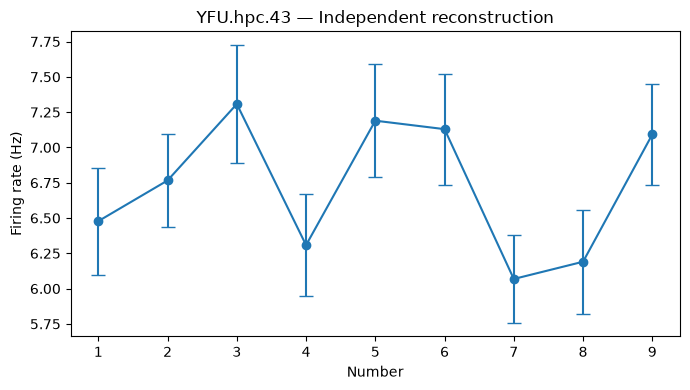

In [64]:
plt.figure(figsize=(7, 4))

plt.errorbar(
    yfu43_tuning["number"],
    yfu43_tuning["mean_firing_rate"],
    yerr=yfu43_tuning["sem_firing_rate"],
    marker="o",
    capsize=5
)

plt.xticks(range(1, 10))
plt.xlabel("Number")
plt.ylabel("Firing rate (Hz)")
plt.title("YFU.hpc.43 — Independent reconstruction")

plt.tight_layout()

# Save figure
plt.savefig(
    "../figures/figure1D_YFU_hpc43_reproduction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Single-neuron number decoding
### Validation on YFU.hpc.43

Temporal pattern > LDA decoder > cross validation accuracy >> permutation test > p value on (is the decoding genuinely above any chance 1/9)


90 ms bin as eg

In [65]:
bin_ms = 90
neuron_id = 42

temporal_rows = []

for _, trial in yfu_aligned.iterrows():

    if trial["toExclude"] != 0:
        continue

    # Operand 1 and Operand 2 are treated as number presentations
    for number_col, time_col, position in [
        ("cue1", "operand1_time", 1),
        ("cue2", "operand2_time", 2)
    ]:

        number = int(trial[number_col])

        # Figures 1–3 use numbers 1–9
        if not (1 <= number <= 9):
            continue

        onset = trial[time_col]

        start_ms = int(round(onset + 50))
        end_ms   = int(round(onset + 950))

        # Extract the full 900-ms binary spike train
        window = yfu_spike_matrix[
            neuron_id,
            start_ms:end_ms
        ].toarray().ravel()

        # Divide into 90-ms bins
        n_bins = 900 // bin_ms

        binned_counts = window.reshape(
            n_bins,
            bin_ms
        ).sum(axis=1)

        temporal_rows.append({
            "trial": int(trial["trial"]),
            "operand_position": position,
            "number": number,
            "features": binned_counts
        })

In [66]:
X = np.vstack([
    row["features"]
    for row in temporal_rows
])

y = np.array([
    row["number"]
    for row in temporal_rows
])

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst temporal pattern:")
print(X[0])

print("Its number label:")
print(y[0])

X shape: (494, 10)
y shape: (494,)

First temporal pattern:
[1 0 1 0 0 0 0 0 2 2]
Its number label:
7


pooled opeerand 1 and 2 , filtered ,  1-9 so 494 trials 

            90-ms temporal bins
          ↓  ↓  ↓              ↓
X row = [b1 b2 b3 b4 b5 b6 b7 b8 b9 b10]

In [67]:
X

array([[1, 0, 1, ..., 0, 2, 2],
       [2, 2, 0, ..., 2, 0, 0],
       [1, 0, 1, ..., 0, 1, 0],
       ...,
       [1, 1, 0, ..., 0, 0, 1],
       [0, 2, 0, ..., 0, 0, 2],
       [1, 2, 0, ..., 1, 0, 0]], shape=(494, 10), dtype=uint64)

In [69]:
900/90

10.0

In [70]:
y

array([7, 8, 7, 4, 7, 6, 5, 8, 4, 4, 2, 7, 3, 3, 2, 4, 4, 6, 4, 7, 3, 7,
       7, 8, 9, 7, 7, 7, 1, 8, 3, 7, 3, 5, 7, 4, 7, 5, 2, 6, 9, 7, 3, 2,
       6, 9, 6, 6, 3, 9, 4, 5, 5, 1, 2, 7, 3, 6, 3, 3, 2, 4, 3, 5, 8, 9,
       8, 9, 6, 5, 3, 2, 8, 2, 3, 2, 5, 2, 1, 5, 2, 2, 7, 7, 4, 8, 4, 7,
       6, 8, 7, 9, 1, 8, 6, 6, 4, 1, 1, 2, 4, 1, 2, 7, 7, 8, 8, 4, 9, 9,
       7, 1, 3, 5, 1, 6, 3, 1, 8, 4, 9, 6, 7, 5, 8, 5, 1, 6, 3, 8, 3, 4,
       2, 4, 7, 4, 2, 3, 4, 4, 8, 9, 4, 7, 7, 6, 9, 5, 1, 1, 8, 2, 7, 6,
       3, 1, 5, 9, 2, 3, 4, 9, 5, 6, 8, 8, 9, 6, 6, 6, 9, 5, 4, 8, 9, 7,
       3, 1, 6, 6, 3, 5, 2, 8, 7, 1, 5, 6, 1, 2, 2, 3, 4, 4, 7, 3, 5, 5,
       8, 3, 7, 9, 3, 3, 3, 9, 7, 7, 7, 1, 9, 1, 1, 7, 5, 1, 7, 7, 6, 1,
       7, 2, 2, 2, 2, 3, 1, 1, 3, 4, 6, 5, 7, 4, 4, 8, 4, 9, 4, 1, 2, 5,
       3, 6, 6, 8, 8, 9, 6, 9, 8, 9, 7, 4, 4, 8, 8, 5, 6, 4, 5, 7, 2, 7,
       3, 9, 8, 9, 4, 2, 5, 4, 7, 1, 3, 3, 7, 4, 2, 6, 2, 8, 5, 3, 3, 9,
       5, 1, 6, 8, 4, 8, 4, 6, 9, 4, 2, 2, 2, 9, 8,

In [71]:
y[0]

np.int64(7)

In [75]:
X[0]

array([1, 0, 1, 0, 0, 0, 0, 0, 2, 2], dtype=uint64)

In [76]:
unique, counts = np.unique(y, return_counts=True)

for number, count in zip(unique, counts):
    print(f"Number {number}: {count} presentations")

Number 1: 53 presentations
Number 2: 67 presentations
Number 3: 52 presentations
Number 4: 62 presentations
Number 5: 51 presentations
Number 6: 48 presentations
Number 7: 65 presentations
Number 8: 49 presentations
Number 9: 47 presentations


# use 10-fold stratified cross-validation.Train first  LDA decoder

Using grid search to find best bins and gamma

10 different bnin sizes and 3 gamma values(overfititng regulariser) = 30combnations

One implementation detail: scikit-learn's LDA uses shrinkage, where the shrinkage value corresponds to the regularization role of MATLAB's Gamma for our reproduction. We'll use the lsqr solver because sklearn requires it (or eigen) when shrinkage is enabled.

In [81]:
import sklearn
print(sklearn.__version__)

1.9.0


In [82]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

Temporary single choice of gamma 0.5 and bin size =90

In [85]:
import numpy as np

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score


# --------------------------------------------------
# Settings for our FIRST test
# --------------------------------------------------

gamma = 0.5
n_folds = 10

cv = StratifiedKFold(
    n_splits=n_folds,
    shuffle=True,
    random_state=42
)

fold_accuracies = []


# --------------------------------------------------
# 10-fold cross-validation
# --------------------------------------------------

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):

    X_train = X[train_idx]
    X_test  = X[test_idx]

    y_train = y[train_idx]
    y_test  = y[test_idx]


    # ----------------------------------------------
    # Remove features with zero within-class variance
    # in the TRAINING data
    # ----------------------------------------------

    keep_features = []

    for j in range(X_train.shape[1]):

        has_variance = True

        for number in np.unique(y_train):

            class_values = X_train[y_train == number, j]

            if np.var(class_values) == 0:
                has_variance = False
                break

        if has_variance:
            keep_features.append(j)


    X_train_filtered = X_train[:, keep_features]
    X_test_filtered  = X_test[:, keep_features]


    # ----------------------------------------------
    # LDA
    # ----------------------------------------------

    lda = LinearDiscriminantAnalysis(
        solver="lsqr",
        shrinkage=gamma,
        priors=np.ones(9) / 9
    )

    lda.fit(X_train_filtered, y_train)


    # ----------------------------------------------
    # Predict held-out trials
    # ----------------------------------------------

    y_pred = lda.predict(X_test_filtered)

    accuracy = accuracy_score(y_test, y_pred)

    fold_accuracies.append(accuracy)

    print(
        f"Fold {fold}: "
        f"accuracy = {accuracy:.3f}, "
        f"features kept = {len(keep_features)}"
    )

Fold 1: accuracy = 0.120, features kept = 10
Fold 2: accuracy = 0.180, features kept = 10
Fold 3: accuracy = 0.080, features kept = 10
Fold 4: accuracy = 0.100, features kept = 10
Fold 5: accuracy = 0.163, features kept = 10
Fold 6: accuracy = 0.204, features kept = 10
Fold 7: accuracy = 0.041, features kept = 10
Fold 8: accuracy = 0.184, features kept = 10
Fold 9: accuracy = 0.061, features kept = 10
Fold 10: accuracy = 0.061, features kept = 10


features kept = number of bins, ( input from R^10)

 paper's Methods specifies 10-fold cross-validation. we can change too

....code for 
lda = LinearDiscriminantAnalysis(
    solver="lsqr",
    shrinkage=gamma,
    priors=np.ones(9) / 9
)

lda.fit(X_train_filtered, y_train)

Scikit-learn's LinearDiscriminantAnalysis does not have an argument literally called gamma , used shrinkage ==gamma

In [86]:
mean_accuracy = np.mean(fold_accuracies)

print("\nMean 10-fold CV accuracy:")
print(f"{mean_accuracy:.3f}")

print("\nPercentage:")
print(f"{mean_accuracy * 100:.2f}%")

print("\nNaive 9-class chance level:")
print(f"{100/9:.2f}%")


Mean 10-fold CV accuracy:
0.119

Percentage:
11.94%

Naive 9-class chance level:
11.11%


the above is the mean of all folds 


Cross-validation is not classifier(lda here). It is the procedure we use to test how well LDA generalizes to data it did not train on.(here creating and training folds )

In [87]:
1/9

0.1111111111111111

now best bin and best gamma search using grid search

need to find the find time scale  from bin size : 60,75,90,100,150,180,225,300,450,900 ms. and gamam regulisers(  0.2,0.5,0.8) -10 x 3 == 
30 combinations

# corection in shrinkage in MAtlab gamma

In [88]:
import numpy as np

def matlab_gamma_lda_predict(X_train, y_train, X_test, gamma):
    """
    Linear discriminant classifier approximating MATLAB fitcdiscr
    with:
      - linear discriminant
      - Gamma regularization
      - uniform class priors
    """

    classes = np.unique(y_train)
    n_features = X_train.shape[1]

    # Class means
    class_means = {
        c: X_train[y_train == c].mean(axis=0)
        for c in classes
    }

    # ----- pooled within-class covariance -----

    centered_parts = []

    for c in classes:
        Xc = X_train[y_train == c]
        centered_parts.append(Xc - class_means[c])

    X_centered = np.vstack(centered_parts)

    # Pooled covariance
    Sigma = np.cov(X_centered, rowvar=False, bias=False)

    # Handle one-feature case
    if np.ndim(Sigma) == 0:
        Sigma = np.array([[Sigma]])

    # ----- MATLAB-style Gamma regularization -----

    D = np.diag(np.diag(Sigma))

    Sigma_reg = (
        (1 - gamma) * Sigma
        + gamma * D
    )

    # Numerical inverse
    Sigma_inv = np.linalg.pinv(Sigma_reg)

    # Uniform class prior
    log_prior = np.log(1 / len(classes))

    predictions = []

    for x in X_test:

        scores = []

        for c in classes:
            mu = class_means[c]

            # Linear discriminant score
            score = (
                x @ Sigma_inv @ mu
                - 0.5 * mu @ Sigma_inv @ mu
                + log_prior
            )

            scores.append(score)

        predictions.append(classes[np.argmax(scores)])

    return np.array(predictions)

In [89]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

gamma = 0.5

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

all_true = []
all_pred = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):

    X_train = X[train_idx]
    X_test = X[test_idx]

    y_train = y[train_idx]
    y_test = y[test_idx]

    # -----------------------------------
    # Remove zero-within-class-variance features
    # using TRAINING data only
    # -----------------------------------

    keep_features = []

    for j in range(X_train.shape[1]):

        valid = True

        for number in np.unique(y_train):

            values = X_train[y_train == number, j]

            if np.var(values) == 0:
                valid = False
                break

        if valid:
            keep_features.append(j)

    X_train_f = X_train[:, keep_features]
    X_test_f = X_test[:, keep_features]

    # -----------------------------------
    # MATLAB-style Gamma LDA
    # -----------------------------------

    y_pred = matlab_gamma_lda_predict(
        X_train_f,
        y_train,
        X_test_f,
        gamma=gamma
    )

    fold_accuracy = accuracy_score(y_test, y_pred)

    print(
        f"Fold {fold}: "
        f"accuracy = {fold_accuracy:.3f}, "
        f"features kept = {len(keep_features)}"
    )

    all_true.extend(y_test)
    all_pred.extend(y_pred)


overall_accuracy = accuracy_score(all_true, all_pred)

print("\nOverall held-out accuracy:")
print(f"{overall_accuracy:.3f}")
print(f"{overall_accuracy * 100:.2f}%")

Fold 1: accuracy = 0.120, features kept = 10
Fold 2: accuracy = 0.180, features kept = 10
Fold 3: accuracy = 0.080, features kept = 10
Fold 4: accuracy = 0.100, features kept = 10
Fold 5: accuracy = 0.163, features kept = 10
Fold 6: accuracy = 0.204, features kept = 10
Fold 7: accuracy = 0.041, features kept = 10
Fold 8: accuracy = 0.163, features kept = 10
Fold 9: accuracy = 0.061, features kept = 10
Fold 10: accuracy = 0.061, features kept = 10

Overall held-out accuracy:
0.117
11.74%


Best parameter search 

for each combination ( total 30 )

-rebuild the temporal feature matrix,
-run 10-fold stratified CV,
-use our MATLAB-style Gamma LDA,
-record overall held-out accuracy.

In [93]:
bin_sizes = [60, 75, 90, 100, 150, 180, 225, 300, 450, 900]
gammas = [0.2, 0.5, 0.8]

grid_results = []

for bin_ms in bin_sizes:

    # -----------------------------------
    # Build temporal features for this bin size
    # -----------------------------------

    temporal_rows = []

    for _, trial in yfu_aligned.iterrows():

        if trial["toExclude"] != 0:
            continue

        for number_col, time_col in [
            ("cue1", "operand1_time"),
            ("cue2", "operand2_time"),
        ]:

            number = int(trial[number_col])

            if not (1 <= number <= 9):
                continue

            onset = trial[time_col]

            start_ms = int(round(onset + 50))
            end_ms   = int(round(onset + 950))

            window = yfu_spike_matrix[
                42,
                start_ms:end_ms
            ].toarray().ravel()

            n_bins = 900 // bin_ms

            binned_counts = window.reshape(
                n_bins,
                bin_ms
            ).sum(axis=1)

            temporal_rows.append({
                "number": number,
                "features": binned_counts
            })

    X_bin = np.vstack([
        row["features"]
        for row in temporal_rows
    ])

    y_bin = np.array([
        row["number"]
        for row in temporal_rows
    ])

    # -----------------------------------
    # Try each Gamma
    # -----------------------------------

    for gamma in gammas:

        cv = StratifiedKFold(
            n_splits=10,
            shuffle=True,
            random_state=42
        )

        all_true = []
        all_pred = []

        for train_idx, test_idx in cv.split(X_bin, y_bin):

            X_train = X_bin[train_idx]
            X_test  = X_bin[test_idx]

            y_train = y_bin[train_idx]
            y_test  = y_bin[test_idx]

            # Remove features with zero within-class variance
            # using training data only
            keep_features = []

            for j in range(X_train.shape[1]):

                valid = True

                for number in np.unique(y_train):

                    vals = X_train[y_train == number, j]

                    if np.var(vals) == 0:
                        valid = False
                        break

                if valid:
                    keep_features.append(j)

            # Skip pathological cases
            if len(keep_features) == 0:
                continue

            X_train_f = X_train[:, keep_features]
            X_test_f  = X_test[:, keep_features]

            y_pred = matlab_gamma_lda_predict(
                X_train_f,
                y_train,
                X_test_f,
                gamma=gamma
            )

            all_true.extend(y_test)
            all_pred.extend(y_pred)

        accuracy = accuracy_score(
            all_true,
            all_pred
        )

        grid_results.append({
            "bin_ms": bin_ms,
            "n_bins": 900 // bin_ms,
            "gamma": gamma,
            "accuracy": accuracy
        })


grid_results = pd.DataFrame(grid_results)

grid_results

,bin_ms,n_bins,gamma,accuracy
0,60,15,0.2,0.121457
1,60,15,0.5,0.119433
2,60,15,0.8,0.121457
3,75,12,0.2,0.139676
4,75,12,0.5,0.143725
5,75,12,0.8,0.135628
6,90,10,0.2,0.115385
7,90,10,0.5,0.117409
8,90,10,0.8,0.117409
9,100,9,0.2,0.119433


In [94]:
grid_results_sorted = grid_results.sort_values(
    "accuracy",
    ascending=False
).reset_index(drop=True)

grid_results_sorted.head(10)

,bin_ms,n_bins,gamma,accuracy
0,150,6,0.8,0.149798
1,150,6,0.2,0.147773
2,150,6,0.5,0.145749
3,75,12,0.5,0.143725
4,75,12,0.2,0.139676
5,75,12,0.8,0.135628
6,180,5,0.5,0.123482
7,60,15,0.2,0.121457
8,60,15,0.8,0.121457
9,60,15,0.5,0.119433


In [95]:
best = grid_results_sorted.iloc[0]

print("Best bin size:", best["bin_ms"], "ms")
print("Number of temporal bins:", int(best["n_bins"]))
print("Best Gamma:", best["gamma"])
print("Best CV accuracy:", f"{best['accuracy'] * 100:.2f}%")

Best bin size: 150.0 ms
Number of temporal bins: 6
Best Gamma: 0.8
Best CV accuracy: 14.98%


The above is for this particaular neuron YFU.hpc.43

does this accuracy mean , this neuron is significantly number coding 
, find p values by pemutation test 

number coding neuron ( neurons  that help us(contain info) to decode the patterns to numbers ),, here , - if pvalue(permutation test )<0.05 implies number coding neuron

Permutation test : if number labels were meaningless, how often could we get ≥14.98%  (actual accuracy )?
so fix patteren , randomly change the labels , and expect the number of times the shuffled accuracy is greater than actual accuracy (14.98) to be small ....

# rebuld X using best parameters with labels (numbers/output) permuted 

In [96]:
best_bin = 150
best_gamma = 0.8

temporal_rows = []

for _, trial in yfu_aligned.iterrows():

    if trial["toExclude"] != 0:
        continue

    for number_col, time_col in [
        ("cue1", "operand1_time"),
        ("cue2", "operand2_time")
    ]:

        number = int(trial[number_col])

        if not (1 <= number <= 9):
            continue

        onset = trial[time_col]

        start_ms = int(round(onset + 50))
        end_ms   = int(round(onset + 950))

        window = yfu_spike_matrix[
            42,
            start_ms:end_ms
        ].toarray().ravel()

        binned_counts = window.reshape(
            6, 150
        ).sum(axis=1)

        temporal_rows.append({
            "number": number,
            "features": binned_counts
        })

X_best = np.vstack([r["features"] for r in temporal_rows])
y_best = np.array([r["number"] for r in temporal_rows])

print("X:", X_best.shape)
print("y:", y_best.shape)

X: (494, 6)
y: (494,)


In [97]:
def cv_decode_accuracy(X, y, gamma, random_state=42):

    cv = StratifiedKFold(
        n_splits=10,
        shuffle=True,
        random_state=random_state
    )

    all_true = []
    all_pred = []

    for train_idx, test_idx in cv.split(X, y):

        X_train = X[train_idx]
        X_test  = X[test_idx]

        y_train = y[train_idx]
        y_test  = y[test_idx]

        # Remove zero-within-class-variance features
        # using TRAINING data only
        keep_features = []

        for j in range(X_train.shape[1]):

            valid = True

            for number in np.unique(y_train):

                vals = X_train[y_train == number, j]

                if np.var(vals) == 0:
                    valid = False
                    break

            if valid:
                keep_features.append(j)

        if len(keep_features) == 0:
            continue

        X_train_f = X_train[:, keep_features]
        X_test_f  = X_test[:, keep_features]

        y_pred = matlab_gamma_lda_predict(
            X_train_f,
            y_train,
            X_test_f,
            gamma=gamma
        )

        all_true.extend(y_test)
        all_pred.extend(y_pred)

    return accuracy_score(all_true, all_pred)

In [98]:
observed_accuracy = cv_decode_accuracy(
    X_best,
    y_best,
    gamma=best_gamma
)

print(f"Observed accuracy: {observed_accuracy * 100:.2f}%")

Observed accuracy: 14.98%


# Shuffle(relabelling) 200 times 

In [99]:
rng = np.random.default_rng(42)

n_shuffles = 200
shuffle_accuracies = []

for i in range(n_shuffles):

    # Keep X exactly the same.
    # Destroy only X <-> number association.
    y_shuffle = rng.permutation(y_best)

    shuffle_accuracy = cv_decode_accuracy(
        X_best,
        y_shuffle,
        gamma=best_gamma
    )

    shuffle_accuracies.append(shuffle_accuracy)

    if (i + 1) % 20 == 0:
        print(f"Completed {i + 1}/200 shuffles")

Completed 20/200 shuffles
Completed 40/200 shuffles
Completed 60/200 shuffles
Completed 80/200 shuffles
Completed 100/200 shuffles
Completed 120/200 shuffles
Completed 140/200 shuffles
Completed 160/200 shuffles
Completed 180/200 shuffles
Completed 200/200 shuffles


X unchangd, y changes 

permutation p values 


In [100]:
shuffle_accuracies = np.array(shuffle_accuracies)

n_extreme = np.sum(
    shuffle_accuracies >= observed_accuracy
)

p_value = (1 + n_extreme) / (1 + n_shuffles)

print("Observed accuracy:",
      f"{observed_accuracy * 100:.2f}%")

print("Mean shuffled accuracy:",
      f"{shuffle_accuracies.mean() * 100:.2f}%")

print("Shuffles >= observed:",
      n_extreme)

print("Permutation p-value:",
      f"{p_value:.4f}")

if p_value < 0.05:
    print("SIGNIFICANT: number-coding neuron")
else:
    print("NOT significant")

Observed accuracy: 14.98%
Mean shuffled accuracy: 10.93%
Shuffles >= observed: 1
Permutation p-value: 0.0100
SIGNIFICANT: number-coding neuron


p = 1 + (1)/ 200  +1 ( that 1 is for including the original data too )

In [101]:
1/200

0.005

In [102]:
2/201

0.009950248756218905

p value < 0.05 , reject the null .. 

null hypothesis: The neuron does not encode number information, and any observed decoding accuracy is due to chance.(ie.pattern is independent of numbers )

## Result :   YFU.hpc.43 is a significant temporal number coding neuron 

---


# Single function to do LDA decoding , cross validation and permutation test on number neuron coding'

Temporal features

In [103]:
def build_temporal_features(
    spike_matrix,
    behav_aligned,
    neuron_id,
    bin_ms
):
    """
    Build temporal spike-count features for one neuron.

    Uses:
      - Operand 1 + Operand 2 presentations
      - numbers 1–9 only
      - toExclude == 0
      - 50–950 ms after operand onset
    """

    rows = []

    n_bins = 900 // bin_ms

    for _, trial in behav_aligned.iterrows():

        if trial["toExclude"] != 0:
            continue

        for number_col, time_col in [
            ("cue1", "operand1_time"),
            ("cue2", "operand2_time"),
        ]:

            number = int(trial[number_col])

            if not (1 <= number <= 9):
                continue

            onset = trial[time_col]

            start_ms = int(round(onset + 50))
            end_ms   = int(round(onset + 950))

            window = spike_matrix[
                neuron_id,
                start_ms:end_ms
            ].toarray().ravel()

            binned_counts = window.reshape(
                n_bins,
                bin_ms
            ).sum(axis=1)

            rows.append({
                "number": number,
                "features": binned_counts
            })

    X = np.vstack([r["features"] for r in rows])
    y = np.array([r["number"] for r in rows])

    return X, y

CV function


In [104]:
def cv_decode_accuracy(
    X,
    y,
    gamma,
    random_state=42
):
    """
    Cross-validated MATLAB-style Gamma LDA accuracy.
    """

    classes, counts = np.unique(
        y,
        return_counts=True
    )

    min_count = counts.min()

    # Paper requests 10 folds, but reduce if needed
    n_folds = min(10, int(min_count))

    if n_folds < 2:
        return np.nan, n_folds

    cv = StratifiedKFold(
        n_splits=n_folds,
        shuffle=True,
        random_state=random_state
    )

    all_true = []
    all_pred = []

    for train_idx, test_idx in cv.split(X, y):

        X_train = X[train_idx]
        X_test  = X[test_idx]

        y_train = y[train_idx]
        y_test  = y[test_idx]

        # ----------------------------------
        # Feature filtering
        # ----------------------------------

        keep_features = []

        for j in range(X_train.shape[1]):

            valid = True

            for number in classes:

                values = X_train[
                    y_train == number,
                    j
                ]

                if len(values) == 0 or np.var(values) == 0:
                    valid = False
                    break

            if valid:
                keep_features.append(j)

        if len(keep_features) == 0:
            return np.nan, n_folds

        X_train_f = X_train[:, keep_features]
        X_test_f  = X_test[:, keep_features]

        # ----------------------------------
        # LDA
        # ----------------------------------

        y_pred = matlab_gamma_lda_predict(
            X_train_f,
            y_train,
            X_test_f,
            gamma=gamma
        )

        all_true.extend(y_test)
        all_pred.extend(y_pred)

    accuracy = accuracy_score(
        all_true,
        all_pred
    )

    return accuracy, n_folds

Complete one neuron decoder

In [105]:
def decode_one_neuron(
    spike_matrix,
    behav_aligned,
    neuron_id,
    n_shuffles=200,
    random_state=42
):
    """
    Full temporal number-decoding pipeline for one neuron.

    Returns:
      - optimal temporal bin size
      - optimal Gamma
      - cross-validated decoding accuracy
      - permutation p-value
      - significance / number-coding classification
    """

    bin_sizes = [
        60, 75, 90, 100, 150,
        180, 225, 300, 450, 900
    ]

    gammas = [0.2, 0.5, 0.8]

    grid_rows = []

    # ==================================================
    # 1. GRID SEARCH
    # ==================================================

    for bin_ms in bin_sizes:

        X, y = build_temporal_features(
            spike_matrix,
            behav_aligned,
            neuron_id,
            bin_ms
        )

        for gamma in gammas:

            accuracy, n_folds = cv_decode_accuracy(
                X,
                y,
                gamma=gamma,
                random_state=random_state
            )

            grid_rows.append({
                "bin_ms": bin_ms,
                "n_bins": 900 // bin_ms,
                "gamma": gamma,
                "accuracy": accuracy,
                "n_folds": n_folds
            })

    grid = pd.DataFrame(grid_rows)

    grid = grid.sort_values(
        "accuracy",
        ascending=False
    ).reset_index(drop=True)

    # ==================================================
    # 2. BEST PARAMETERS
    # ==================================================

    best = grid.iloc[0]

    best_bin = int(best["bin_ms"])
    best_gamma = float(best["gamma"])
    observed_accuracy = float(best["accuracy"])
    n_folds = int(best["n_folds"])

    # Rebuild X using winning temporal resolution
    X_best, y_best = build_temporal_features(
        spike_matrix,
        behav_aligned,
        neuron_id,
        best_bin
    )

    # ==================================================
    # 3. PERMUTATION TEST
    # ==================================================

    rng = np.random.default_rng(
        random_state
    )

    shuffle_accuracies = []

    for i in range(n_shuffles):

        y_shuffle = rng.permutation(
            y_best
        )

        shuffle_accuracy, _ = cv_decode_accuracy(
            X_best,
            y_shuffle,
            gamma=best_gamma,
            random_state=random_state
        )

        shuffle_accuracies.append(
            shuffle_accuracy
        )

    shuffle_accuracies = np.array(
        shuffle_accuracies
    )

    # ==================================================
    # 4. PERMUTATION P-VALUE
    # ==================================================

    n_extreme = np.sum(
        shuffle_accuracies
        >= observed_accuracy
    )

    p_value = (
        1 + n_extreme
    ) / (
        1 + n_shuffles
    )

    significant = p_value < 0.05

    # ==================================================
    # 5. RESULT
    # ==================================================

    result = {
        "neuron_id": neuron_id,

        "best_bin_ms": best_bin,
        "n_temporal_bins": 900 // best_bin,
        "best_gamma": best_gamma,

        "n_folds": n_folds,

        "observed_accuracy": observed_accuracy,

        "mean_shuffle_accuracy":
            shuffle_accuracies.mean(),

        "n_shuffles_ge_observed":
            int(n_extreme),

        "p_value": p_value,

        "number_coding": significant
    }

    return result, grid, shuffle_accuracies

## test on YFU.hpc 43

In [106]:
result_43, grid_43, shuffles_43 = decode_one_neuron(
    yfu_spike_matrix,
    yfu_aligned,
    neuron_id=42,
    n_shuffles=200,
    random_state=42
)

In [107]:
result_43

{'neuron_id': 42,
 'best_bin_ms': 150,
 'n_temporal_bins': 6,
 'best_gamma': 0.8,
 'n_folds': 10,
 'observed_accuracy': 0.14979757085020243,
 'mean_shuffle_accuracy': np.float64(0.10932186234817813),
 'n_shuffles_ge_observed': 1,
 'p_value': np.float64(0.009950248756218905),
 'number_coding': np.True_}

In [108]:
grid_43.head(10)

,bin_ms,n_bins,gamma,accuracy,n_folds
0,150,6,0.8,0.149798,10
1,150,6,0.2,0.147773,10
2,150,6,0.5,0.145749,10
3,75,12,0.5,0.143725,10
4,75,12,0.2,0.139676,10
5,75,12,0.8,0.135628,10
6,180,5,0.5,0.123482,10
7,60,15,0.2,0.121457,10
8,60,15,0.8,0.121457,10
9,60,15,0.5,0.119433,10


test on yfu 30 

In [109]:
test_neuron = 30

print("Neuron row:", test_neuron)
print("Region:", yfu_region_labels[test_neuron])

Neuron row: 30
Region: hpc


In [110]:
result_30, grid_30, shuffles_30 = decode_one_neuron(
    yfu_spike_matrix,
    yfu_aligned,
    neuron_id=30,
    n_shuffles=200,
    random_state=42
)

result_30

{'neuron_id': 30,
 'best_bin_ms': 900,
 'n_temporal_bins': 1,
 'best_gamma': 0.2,
 'n_folds': 10,
 'observed_accuracy': 0.1437246963562753,
 'mean_shuffle_accuracy': np.float64(0.11091093117408908),
 'n_shuffles_ge_observed': 2,
 'p_value': np.float64(0.014925373134328358),
 'number_coding': np.True_}

In [111]:
grid_30.head(10)

,bin_ms,n_bins,gamma,accuracy,n_folds
0,900,1,0.2,0.143725,10
1,900,1,0.8,0.143725,10
2,900,1,0.5,0.143725,10
3,300,3,0.2,0.141700,10
4,300,3,0.8,0.141700,10
5,300,3,0.5,0.141700,10
6,450,2,0.5,0.139676,10
7,450,2,0.2,0.139676,10
8,450,2,0.8,0.139676,10
9,225,4,0.8,0.137652,10


In [114]:
shuffles_30.mean()

np.float64(0.11091093117408908)

# test on YFF  9

In [115]:
test_neuron = 9

print("Subject: YFF")
print("Neuron row:", test_neuron)
print("Region:", region_labels[test_neuron])

Subject: YFF
Neuron row: 9
Region: hpc


In [116]:
result_yff9, grid_yff9, shuffles_yff9 = decode_one_neuron(
    spike_matrix,       # YFF spike matrix
    yff_aligned,        # YFF aligned behavior
    neuron_id=9,
    n_shuffles=200,
    random_state=42
)

result_yff9

{'neuron_id': 9,
 'best_bin_ms': 900,
 'n_temporal_bins': 1,
 'best_gamma': 0.2,
 'n_folds': 7,
 'observed_accuracy': 0.1651376146788991,
 'mean_shuffle_accuracy': np.float64(0.10555045871559633),
 'n_shuffles_ge_observed': 9,
 'p_value': np.float64(0.04975124378109453),
 'number_coding': np.True_}

## test on YFF.ent.8

In [123]:
for i, region in enumerate(region_labels):
    if region in ["ent"]:
        print(i, region)

8 ent


In [124]:
result_yff_ent8, grid_yff_ent8, shuffles_yff_ent8 = decode_one_neuron(
    spike_matrix,
    yff_aligned,
    neuron_id=8,
    n_shuffles=200,
    random_state=42
)

result_yff_ent8

{'neuron_id': 8,
 'best_bin_ms': 180,
 'n_temporal_bins': 5,
 'best_gamma': 0.5,
 'n_folds': 7,
 'observed_accuracy': 0.14678899082568808,
 'mean_shuffle_accuracy': np.float64(0.10605504587155963),
 'n_shuffles_ge_observed': 23,
 'p_value': np.float64(0.11940298507462686),
 'number_coding': np.False_}

# YFF.ent .8 is not numbr coding neuron 

---

| Neuron     | Region | Best bin | Accuracy |    (p) | Number-coding? |
| ---------- | ------ | -------: | -------: | -----: | -------------- |
| YFU row 42 | HPC    |   150 ms |   14.98% | 0.0100 |  Yes          |
| YFU row 30 | HPC    |   900 ms |   14.37% | 0.0149 |  Yes          |
| YFF row 8  | ENT    |   180 ms |   14.68% | 0.1194 | --.. No           |
